# Election Bloc Change Prediction Project
## Notebook 02 — Election Transition Panel and Target Engineering

> **FULL-HISTORY CORRECTED VERSION · K16–K25 · NINE TRANSITIONS**

### Purpose

This notebook converts the locality-by-election table created in Notebook 01 into a locality-by-transition modeling table.

Each row represents one locality moving from one election to the next consecutive election.

### The nine transitions

1. Knesset 16 → Knesset 17
2. Knesset 17 → Knesset 18
3. Knesset 18 → Knesset 19
4. Knesset 19 → Knesset 20
5. Knesset 20 → Knesset 21
6. Knesset 21 → Knesset 22
7. Knesset 22 → Knesset 23
8. Knesset 23 → Knesset 24
9. Knesset 24 → Knesset 25

### Main tasks

- Validate that Notebook 01 contains all ten elections, K16–K25.
- Match localities by `locality_symbol` between consecutive elections.
- Audit matched and unmatched localities and vote coverage.
- Create percentage-point and CLR change targets.
- Create explicit persistence-baseline variables.
- Mark only `K24_to_K25` as the locked final-test transition.
- Save and verify all outputs.
- Download all Notebook 02 outputs as a ZIP from the final cell.

### Trusted input

```text
data/interim/election_bloc_results.csv
```

### Main modeling output

```text
data/interim/election_transition_panel.csv
```

## 0. Before running

Run Notebook 01 first. In a fresh Colab runtime, use one of these options:

- upload `notebook_01_outputs.zip` to `/content`; or
- upload `election_bloc_results.csv` directly to `/content`; or
- make sure the current ten-election output is already stored in the GitHub repository.

This notebook automatically prefers an uploaded Notebook 01 output over a repository copy.

In [1]:
from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED
from IPython.display import display
import json
import os
import shutil
import subprocess
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 340)
pd.set_option("display.max_rows", 200)

REPO_URL = (
    "https://github.com/IfatDav/"
    "Election_Bloc_Prediction_Project.git"
)

DEFAULT_REPO_ROOT = Path(
    "/content/Election_Bloc_Prediction_Project"
)

MODELED_BLOCS = [
    "Right",
    "Center_Left",
    "Haredi",
    "Arab",
]

EXPECTED_ELECTION_NUMBERS = list(range(16, 26))
EXPECTED_TRANSITIONS = [
    f"K{number}_to_K{number + 1}"
    for number in range(16, 25)
]

FINAL_TEST_TRANSITION = "K24_to_K25"
CLR_EPSILON = 1e-6
MIN_MATCHED_LOCALITIES = 1000
MIN_MATCHED_VOTE_COVERAGE_PCT = 95.0


def resolve_repository_root():
    """Find an existing project folder or clone the public repository."""
    candidates = []

    explicit_root = os.getenv("ELECTION_PROJECT_ROOT")
    if explicit_root:
        candidates.append(Path(explicit_root).expanduser())

    current = Path.cwd().resolve()
    candidates.extend([
        current,
        *current.parents,
        DEFAULT_REPO_ROOT,
    ])

    checked = set()

    for candidate in candidates:
        try:
            candidate = candidate.resolve()
        except FileNotFoundError:
            continue

        if candidate in checked:
            continue

        checked.add(candidate)

        if (candidate / "data").exists():
            return candidate

    if not Path("/content").exists():
        raise FileNotFoundError(
            "Project folder was not found. Set ELECTION_PROJECT_ROOT."
        )

    if not DEFAULT_REPO_ROOT.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                REPO_URL,
                str(DEFAULT_REPO_ROOT),
            ],
            check=True,
        )

    return DEFAULT_REPO_ROOT


REPO_ROOT = resolve_repository_root()
INTERIM_DIR = REPO_ROOT / "data" / "interim"
TABLES_DIR = REPO_ROOT / "reports" / "tables"
FIGURES_DIR = REPO_ROOT / "reports" / "figures"
SUMMARIES_DIR = REPO_ROOT / "reports" / "summaries"

for directory in [
    INTERIM_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    SUMMARIES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

SOURCE_PATH = INTERIM_DIR / "election_bloc_results.csv"

# Prefer an uploaded Notebook 01 ZIP over a potentially stale repository copy.
uploaded_zips = sorted(
    Path("/content").glob("notebook_01_outputs*.zip"),
    key=lambda path: path.stat().st_mtime,
)

if uploaded_zips:
    uploaded_zip = uploaded_zips[-1]

    with ZipFile(uploaded_zip, mode="r") as zip_file:
        candidate_members = [
            member
            for member in zip_file.namelist()
            if member.endswith(
                "data/interim/election_bloc_results.csv"
            )
            or member.endswith("election_bloc_results.csv")
        ]

        if not candidate_members:
            raise FileNotFoundError(
                f"{uploaded_zip.name} does not contain "
                "election_bloc_results.csv."
            )

        selected_member = candidate_members[0]
        SOURCE_PATH.write_bytes(zip_file.read(selected_member))

    print("Loaded Notebook 01 input from ZIP:", uploaded_zip)

# A directly uploaded CSV also overrides a repository copy.
direct_upload = Path("/content/election_bloc_results.csv")

if direct_upload.exists():
    shutil.copy2(direct_upload, SOURCE_PATH)
    print("Loaded Notebook 01 input from:", direct_upload)

if not SOURCE_PATH.exists():
    raise FileNotFoundError(
        "Notebook 01 output was not found:\n"
        f"{SOURCE_PATH}\n\n"
        "Run Notebook 01 first or upload notebook_01_outputs.zip."
    )

print("Repository root:", REPO_ROOT)
print("Notebook 01 input:", SOURCE_PATH)

Repository root: /content/Election_Bloc_Prediction_Project
Notebook 01 input: /content/Election_Bloc_Prediction_Project/data/interim/election_bloc_results.csv


In [3]:
target_columns = [
    f"{bloc}_pct"
    for bloc in MODELED_BLOCS
]

missing_rows = election_results.loc[
    election_results[target_columns]
    .isna()
    .any(axis=1),
    [
        "locality_symbol",
        "election_locality_name",
        "target_election",
        "election_number",
        "year",
        "valid_votes",
        "modeled_vote_coverage_pct",
        "Other_raw_pct",
        *MODELED_BLOCS,
        *target_columns,
    ],
]

display(missing_rows)

,locality_symbol,election_locality_name,target_election,election_number,year,valid_votes,modeled_vote_coverage_pct,Other_raw_pct,Right,Center_Left,Haredi,Arab,Right_pct,Center_Left_pct,Haredi_pct,Arab_pct
1855,990,ראס עלי,Knesset_17,17,2006,0.0,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


## 1. Load and validate the ten-election input

In [4]:
def normalize_locality_symbol(series):
    """Normalize symbols read from CSV without changing their identity."""
    normalized = series.astype("string").str.strip()
    normalized = normalized.str.replace(
        r"\.0+$",
        "",
        regex=True,
    )
    normalized = normalized.replace(
        {"": pd.NA, "nan": pd.NA, "None": pd.NA}
    )
    return normalized


election_results = pd.read_csv(
    SOURCE_PATH,
    dtype={"locality_symbol": "string"},
    low_memory=False,
)

election_results["locality_symbol"] = normalize_locality_symbol(
    election_results["locality_symbol"]
)

REQUIRED_COLUMNS = [
    "locality_symbol",
    "election_locality_name",
    "target_election",
    "election_number",
    "year",
    "eligible_voters",
    "votes_cast",
    "invalid_votes",
    "valid_votes",
    "turnout_pct",
    "modeled_vote_coverage_pct",
    "Other_raw_pct",
    *MODELED_BLOCS,
    *[f"{bloc}_pct" for bloc in MODELED_BLOCS],
]

missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in election_results.columns
]

if missing_columns:
    raise KeyError(
        "Notebook 01 output is missing required columns:\n- "
        + "\n- ".join(missing_columns)
    )

# Additional Notebook 01 columns are carried forward when available.
OPTIONAL_COLUMNS = [
    "source_row_count",
    "invalid_vote_pct",
    "Other",
    "total_main_blocs",
    *[f"{bloc}_valid_pct" for bloc in MODELED_BLOCS],
]

available_optional_columns = [
    column
    for column in OPTIONAL_COLUMNS
    if column in election_results.columns
]

numeric_columns = [
    "election_number",
    "year",
    "eligible_voters",
    "votes_cast",
    "invalid_votes",
    "valid_votes",
    "turnout_pct",
    "modeled_vote_coverage_pct",
    "Other_raw_pct",
    *MODELED_BLOCS,
    *[f"{bloc}_pct" for bloc in MODELED_BLOCS],
    *available_optional_columns,
]

for column in dict.fromkeys(numeric_columns):
    election_results[column] = (
        pd.to_numeric(
            election_results[column],
            errors="coerce",
        )
        .astype("float64")
    )

election_results["election_number"] = (
    election_results["election_number"].astype("Int64")
)

election_results["year"] = (
    election_results["year"].astype("Int64")
)

# Use one canonical label format regardless of older text values.
election_results["target_election"] = (
    "Knesset_"
    + election_results["election_number"].astype("string")
)

missing_symbols = int(
    election_results["locality_symbol"].isna().sum()
)

if missing_symbols:
    raise ValueError(
        f"Found {missing_symbols} rows without locality_symbol."
    )

duplicate_count = int(
    election_results.duplicated(
        ["locality_symbol", "election_number"]
    ).sum()
)

if duplicate_count:
    raise ValueError(
        f"Found {duplicate_count} duplicate locality-election rows."
    )

actual_election_numbers = sorted(
    election_results["election_number"]
    .dropna()
    .astype(int)
    .unique()
    .tolist()
)

if actual_election_numbers != EXPECTED_ELECTION_NUMBERS:
    raise ValueError(
        "Notebook 01 output must contain every election from K16 to K25.\n"
        f"Expected: {EXPECTED_ELECTION_NUMBERS}\n"
        f"Found: {actual_election_numbers}\n\n"
        "The file being read is stale or incomplete. Upload the current "
        "notebook_01_outputs.zip and run this notebook again."
    )

target_columns = [
    f"{bloc}_pct"
    for bloc in MODELED_BLOCS
]

# Audit and handle missing four-bloc compositions
# --------------------------------------------------

target_missing_mask = (
    election_results[target_columns]
    .isna()
)

all_targets_missing_mask = (
    target_missing_mask.all(axis=1)
)

partial_targets_missing_mask = (
    target_missing_mask.any(axis=1)
    & ~all_targets_missing_mask
)

# Partial missingness indicates a real data-processing error.
partial_missing_rows = int(
    partial_targets_missing_mask.sum()
)

if partial_missing_rows:
    display(
        election_results.loc[
            partial_targets_missing_mask,
            [
                "locality_symbol",
                "election_locality_name",
                "target_election",
                "election_number",
                "valid_votes",
                *MODELED_BLOCS,
                *target_columns,
            ],
        ]
    )

    raise ValueError(
        "Found rows with only some bloc-share targets missing. "
        f"Affected rows: {partial_missing_rows}"
    )

# A row with all four targets missing usually means that
# none of its valid votes belonged to the four modeled blocs.
excluded_missing_compositions = (
    election_results.loc[
        all_targets_missing_mask,
        [
            "locality_symbol",
            "election_locality_name",
            "target_election",
            "election_number",
            "year",
            "valid_votes",
            "modeled_vote_coverage_pct",
            "Other_raw_pct",
            *MODELED_BLOCS,
            *target_columns,
        ],
    ]
    .copy()
)

print(
    "Rows with no defined four-bloc composition:",
    len(excluded_missing_compositions),
)

if not excluded_missing_compositions.empty:
    display(excluded_missing_compositions)

    EXCLUDED_COMPOSITIONS_PATH = (
        TABLES_DIR
        / "excluded_undefined_bloc_compositions.csv"
    )

    excluded_missing_compositions.to_csv(
        EXCLUDED_COMPOSITIONS_PATH,
        index=False,
        encoding="utf-8-sig",
    )

    election_results = (
        election_results.loc[
            ~all_targets_missing_mask
        ]
        .copy()
        .reset_index(drop=True)
    )

# Final check after documented exclusion
missing_target_values = int(
    election_results[
        target_columns
    ]
    .isna()
    .sum()
    .sum()
)

if missing_target_values:
    raise ValueError(
        "Bloc-share targets still contain missing values after "
        f"the exclusion audit. Missing cells: {missing_target_values}"
    )

print(
    "Four-bloc composition validation passed after exclusion."
)

out_of_range_target_values = int(
    (
        election_results[target_columns].lt(-1e-10)
        | election_results[target_columns].gt(100 + 1e-10)
    ).sum().sum()
)

if out_of_range_target_values:
    raise ValueError(
        "The normalized four-bloc shares contain values outside 0–100. "
        f"Invalid cells: {out_of_range_target_values}"
    )

composition_error = (
    election_results[target_columns]
    .sum(axis=1)
    .sub(100)
    .abs()
)

maximum_composition_error = float(composition_error.max())

if maximum_composition_error > 1e-6:
    raise ValueError(
        "Bloc shares do not sum to 100. "
        f"Maximum absolute error: {maximum_composition_error}"
    )

nonpositive_valid_vote_rows = int(
    election_results["valid_votes"].le(0).sum()
)

if nonpositive_valid_vote_rows:
    raise ValueError(
        "The modeling input contains localities with non-positive "
        f"valid_votes: {nonpositive_valid_vote_rows} rows."
    )

input_election_audit = (
    election_results
    .groupby(
        ["election_number", "target_election", "year"],
        as_index=False,
    )
    .agg(
        locality_rows=("locality_symbol", "size"),
        unique_localities=("locality_symbol", "nunique"),
        eligible_voters=("eligible_voters", "sum"),
        votes_cast=("votes_cast", "sum"),
        valid_votes=("valid_votes", "sum"),
        missing_eligible_voters=(
            "eligible_voters",
            lambda values: int(values.isna().sum()),
        ),
        missing_turnout_pct=(
            "turnout_pct",
            lambda values: int(values.isna().sum()),
        ),
    )
    .sort_values("election_number")
    .reset_index(drop=True)
)

display(input_election_audit)

print("Input validation passed.")
print("Elections found:", actual_election_numbers)
print("Maximum composition error:", maximum_composition_error)
print(
    "Note: missing K17 eligible-voter and turnout values are expected "
    "because the historical source does not provide them."
)

Rows with no defined four-bloc composition: 1


,locality_symbol,election_locality_name,target_election,election_number,year,valid_votes,modeled_vote_coverage_pct,Other_raw_pct,Right,Center_Left,Haredi,Arab,Right_pct,Center_Left_pct,Haredi_pct,Arab_pct
1855,990,ראס עלי,Knesset_17,17,2006,0.0,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


Four-bloc composition validation passed after exclusion.


,election_number,target_election,year,locality_rows,unique_localities,eligible_voters,votes_cast,valid_votes,missing_eligible_voters,missing_turnout_pct
0,16,Knesset_16,2003,1171,1171,4720075.0,3042477.0,2992431.0,0,0
1,17,Knesset_17,2006,1148,1148,0.0,3012059.0,2965674.0,1148,1148
2,18,Knesset_18,2009,1156,1156,5278985.0,3229668.0,3189099.0,0,0
3,19,Knesset_19,2013,1184,1184,5656705.0,3617857.0,3579793.0,0,0
4,20,Knesset_20,2015,1195,1195,5881696.0,4020139.0,3978203.0,0,0
5,21,Knesset_21,2019,1213,1213,6339729.0,4099470.0,4070448.0,0,0
6,22,Knesset_22,2019,1213,1213,6391218.0,4182726.0,4156590.0,0,0
7,23,Knesset_23,2020,1213,1213,6453255.0,4284926.0,4262360.0,0,0
8,24,Knesset_24,2021,1214,1214,6578084.0,4010853.0,3988433.0,0,0
9,25,Knesset_25,2022,1215,1215,6788804.0,4331786.0,4306028.0,0,0


Input validation passed.
Elections found: [16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
Maximum composition error: 2.842170943040401e-14
Note: missing K17 eligible-voter and turnout values are expected because the historical source does not provide them.


## 2. Build all nine consecutive-election transitions

In [5]:
columns_to_carry = [
    "locality_symbol",
    "election_locality_name",
    "target_election",
    "year",
    "eligible_voters",
    "votes_cast",
    "invalid_votes",
    "valid_votes",
    "turnout_pct",
    "modeled_vote_coverage_pct",
    "Other_raw_pct",
    *MODELED_BLOCS,
    *[f"{bloc}_pct" for bloc in MODELED_BLOCS],
    *available_optional_columns,
]

# Remove duplicate names while preserving order.
columns_to_carry = list(dict.fromkeys(columns_to_carry))

transition_frames = []
match_audit_rows = []
unmatched_frames = []

for previous_election in range(16, 25):
    current_election = previous_election + 1
    transition_id = f"K{previous_election}_to_K{current_election}"

    previous = election_results.loc[
        election_results["election_number"].eq(previous_election),
        columns_to_carry,
    ].copy()

    current = election_results.loc[
        election_results["election_number"].eq(current_election),
        columns_to_carry,
    ].copy()

    if previous.empty or current.empty:
        raise RuntimeError(
            f"Cannot build {transition_id}: one side is empty."
        )

    previous = previous.add_prefix("previous_").rename(
        columns={"previous_locality_symbol": "locality_symbol"}
    )

    current = current.add_prefix("current_").rename(
        columns={"current_locality_symbol": "locality_symbol"}
    )

    outer = previous.merge(
        current,
        on="locality_symbol",
        how="outer",
        indicator=True,
        validate="one_to_one",
    )

    matched_mask = outer["_merge"].eq("both")

    previous_valid_total = float(
        previous["previous_valid_votes"].sum()
    )
    current_valid_total = float(
        current["current_valid_votes"].sum()
    )
    matched_previous_valid = float(
        outer.loc[matched_mask, "previous_valid_votes"].sum()
    )
    matched_current_valid = float(
        outer.loc[matched_mask, "current_valid_votes"].sum()
    )

    match_audit_rows.append({
        "transition_id": transition_id,
        "previous_election_number": previous_election,
        "current_election_number": current_election,
        "previous_rows": len(previous),
        "current_rows": len(current),
        "matched_rows": int(matched_mask.sum()),
        "previous_only_rows": int(
            outer["_merge"].eq("left_only").sum()
        ),
        "current_only_rows": int(
            outer["_merge"].eq("right_only").sum()
        ),
        "matched_previous_row_coverage_pct": (
            matched_mask.sum() / len(previous) * 100
        ),
        "matched_current_row_coverage_pct": (
            matched_mask.sum() / len(current) * 100
        ),
        "matched_previous_vote_coverage_pct": (
            matched_previous_valid / previous_valid_total * 100
            if previous_valid_total > 0
            else np.nan
        ),
        "matched_current_vote_coverage_pct": (
            matched_current_valid / current_valid_total * 100
            if current_valid_total > 0
            else np.nan
        ),
    })

    unmatched = outer.loc[
        ~matched_mask,
        [
            "locality_symbol",
            "previous_election_locality_name",
            "current_election_locality_name",
            "previous_valid_votes",
            "current_valid_votes",
            "_merge",
        ],
    ].copy()

    unmatched.insert(0, "transition_id", transition_id)
    unmatched = unmatched.rename(columns={"_merge": "match_status"})
    unmatched_frames.append(unmatched)

    matched = outer.loc[matched_mask].drop(columns="_merge").copy()

    matched["previous_election_number"] = previous_election
    matched["current_election_number"] = current_election
    matched["transition_id"] = transition_id
    matched["transition_order"] = previous_election - 16
    matched["final_test_locked"] = (
        transition_id == FINAL_TEST_TRANSITION
    )
    matched["data_role"] = np.where(
        matched["final_test_locked"],
        "final_test",
        "development",
    )
    matched["locality_name"] = (
        matched["current_election_locality_name"]
        .fillna(matched["previous_election_locality_name"])
    )
    matched["locality_name_changed"] = (
        matched["previous_election_locality_name"]
        .fillna("")
        .ne(
            matched["current_election_locality_name"]
            .fillna("")
        )
    )
    matched["year_gap"] = (
        matched["current_year"]
        - matched["previous_year"]
    )

    transition_frames.append(matched)

transition_panel = (
    pd.concat(transition_frames, ignore_index=True)
    .sort_values(["transition_order", "locality_symbol"])
    .reset_index(drop=True)
)

election_transition_match_audit = (
    pd.DataFrame(match_audit_rows)
    .sort_values("previous_election_number")
    .reset_index(drop=True)
)

unmatched_localities_by_transition = pd.concat(
    unmatched_frames,
    ignore_index=True,
)

actual_transitions = (
    transition_panel["transition_id"]
    .drop_duplicates()
    .tolist()
)

if actual_transitions != EXPECTED_TRANSITIONS:
    raise RuntimeError(
        "The transition-building step did not create all nine transitions.\n"
        f"Expected: {EXPECTED_TRANSITIONS}\n"
        f"Found: {actual_transitions}"
    )

print("Transitions created:", actual_transitions)
display(election_transition_match_audit)

Transitions created: ['K16_to_K17', 'K17_to_K18', 'K18_to_K19', 'K19_to_K20', 'K20_to_K21', 'K21_to_K22', 'K22_to_K23', 'K23_to_K24', 'K24_to_K25']


,transition_id,previous_election_number,current_election_number,previous_rows,current_rows,matched_rows,previous_only_rows,current_only_rows,matched_previous_row_coverage_pct,matched_current_row_coverage_pct,matched_previous_vote_coverage_pct,matched_current_vote_coverage_pct
0,K16_to_K17,16,17,1171,1148,1139,32,9,97.267293,99.216028,99.082986,99.970260
1,K17_to_K18,17,18,1148,1156,1140,8,16,99.303136,98.615917,99.894628,99.909818
2,K18_to_K19,18,19,1156,1184,1155,1,29,99.913495,97.550676,99.999937,99.511089
3,K19_to_K20,19,20,1184,1195,1183,1,12,99.915541,98.995816,99.999190,99.958574
4,K20_to_K21,20,21,1195,1213,1193,2,20,99.832636,98.351195,99.995224,99.906570
5,K21_to_K22,21,22,1213,1213,1212,1,1,99.917560,99.917560,99.998600,99.996921
6,K22_to_K23,22,23,1213,1213,1213,0,0,100.000000,100.000000,100.000000,100.000000
7,K23_to_K24,23,24,1213,1214,1211,2,3,99.835120,99.752883,99.988340,99.993958
8,K24_to_K25,24,25,1214,1215,1212,2,3,99.835255,99.753086,99.898607,99.897864


## 3. Create percentage-point and vote-change targets

In [6]:
for bloc in MODELED_BLOCS:
    transition_panel[f"delta_{bloc}_pct"] = (
        transition_panel[f"current_{bloc}_pct"]
        - transition_panel[f"previous_{bloc}_pct"]
    )

    transition_panel[f"absolute_delta_{bloc}_pct"] = (
        transition_panel[f"delta_{bloc}_pct"].abs()
    )

# Preserve changes in raw valid-vote shares when Notebook 01 supplied them.
available_valid_pct_blocs = [
    bloc
    for bloc in MODELED_BLOCS
    if f"previous_{bloc}_valid_pct" in transition_panel.columns
    and f"current_{bloc}_valid_pct" in transition_panel.columns
]

for bloc in available_valid_pct_blocs:
    transition_panel[f"delta_{bloc}_valid_pct"] = (
        transition_panel[f"current_{bloc}_valid_pct"]
        - transition_panel[f"previous_{bloc}_valid_pct"]
    )

transition_panel["delta_turnout_pct"] = (
    transition_panel["current_turnout_pct"]
    - transition_panel["previous_turnout_pct"]
)

transition_panel["delta_Other_raw_pct"] = (
    transition_panel["current_Other_raw_pct"]
    - transition_panel["previous_Other_raw_pct"]
)

transition_panel["valid_vote_growth_pct"] = (
    transition_panel["current_valid_votes"]
    .div(
        transition_panel["previous_valid_votes"].where(
            transition_panel["previous_valid_votes"].gt(0)
        )
    )
    .sub(1)
    .mul(100)
)

transition_panel["log_valid_vote_growth"] = (
    np.log1p(
        transition_panel["current_valid_votes"].clip(lower=0)
    )
    - np.log1p(
        transition_panel["previous_valid_votes"].clip(lower=0)
    )
)

delta_columns = [
    f"delta_{bloc}_pct"
    for bloc in MODELED_BLOCS
]

transition_panel["mean_absolute_bloc_change_pct"] = (
    transition_panel[delta_columns].abs().mean(axis=1)
)
transition_panel["maximum_absolute_bloc_change_pct"] = (
    transition_panel[delta_columns].abs().max(axis=1)
)

missing_delta_values = int(
    transition_panel[delta_columns].isna().sum().sum()
)

if missing_delta_values:
    raise ValueError(
        "Percentage-point targets contain missing values: "
        f"{missing_delta_values} cells."
    )

maximum_delta_sum_error = float(
    transition_panel[delta_columns]
    .sum(axis=1)
    .abs()
    .max()
)

print(
    "Maximum absolute sum of four percentage-point deltas:",
    maximum_delta_sum_error,
)

Maximum absolute sum of four percentage-point deltas: 4.707345624410664e-14


## 4. Create CLR representations and CLR-change targets

Zero components receive a very small additive replacement (`1e-6`) before closure. The inverse-CLR audit verifies that the transformation is numerically reversible.

In [7]:
def close_composition(values, epsilon=CLR_EPSILON):
    values = np.asarray(values, dtype="float64")

    if not np.isfinite(values).all():
        raise ValueError(
            "CLR input contains missing or non-finite values."
        )

    if (values < 0).any():
        raise ValueError("CLR input contains negative shares.")

    replaced = values + epsilon
    row_sums = replaced.sum(axis=1, keepdims=True)

    if (row_sums <= 0).any():
        raise ValueError("CLR input contains a non-positive row sum.")

    return replaced / row_sums


def clr_transform(closed_values):
    logged = np.log(closed_values)
    return logged - logged.mean(axis=1, keepdims=True)


def inverse_clr(clr_values):
    clr_values = np.asarray(clr_values, dtype="float64")
    shifted = clr_values - clr_values.max(axis=1, keepdims=True)
    exponentiated = np.exp(shifted)
    return exponentiated / exponentiated.sum(axis=1, keepdims=True)


previous_share_columns = [
    f"previous_{bloc}_pct"
    for bloc in MODELED_BLOCS
]
current_share_columns = [
    f"current_{bloc}_pct"
    for bloc in MODELED_BLOCS
]

previous_closed = close_composition(
    transition_panel[previous_share_columns].to_numpy(
        dtype="float64"
    )
)
current_closed = close_composition(
    transition_panel[current_share_columns].to_numpy(
        dtype="float64"
    )
)

previous_clr = clr_transform(previous_closed)
current_clr = clr_transform(current_closed)
delta_clr = current_clr - previous_clr

for index, bloc in enumerate(MODELED_BLOCS):
    transition_panel[f"previous_clr_{bloc}"] = previous_clr[:, index]
    transition_panel[f"current_clr_{bloc}"] = current_clr[:, index]
    transition_panel[f"delta_clr_{bloc}"] = delta_clr[:, index]

previous_reconstruction_error = np.abs(
    inverse_clr(previous_clr) - previous_closed
)
current_reconstruction_error = np.abs(
    inverse_clr(current_clr) - current_closed
)

clr_transformation_audit = pd.DataFrame({
    "metric": [
        "clr_zero_replacement_epsilon",
        "maximum_previous_inverse_clr_error",
        "maximum_current_inverse_clr_error",
        "maximum_previous_clr_row_sum",
        "maximum_current_clr_row_sum",
        "maximum_delta_clr_row_sum",
    ],
    "value": [
        CLR_EPSILON,
        float(previous_reconstruction_error.max()),
        float(current_reconstruction_error.max()),
        float(np.abs(previous_clr.sum(axis=1)).max()),
        float(np.abs(current_clr.sum(axis=1)).max()),
        float(np.abs(delta_clr.sum(axis=1)).max()),
    ],
})

display(clr_transformation_audit)

,metric,value
0,clr_zero_replacement_epsilon,1.000000e-06
1,maximum_previous_inverse_clr_error,5.551115e-16
2,maximum_current_inverse_clr_error,5.551115e-16
3,maximum_previous_clr_row_sum,7.105427e-15
4,maximum_current_clr_row_sum,7.105427e-15
5,maximum_delta_clr_row_sum,1.065814e-14


## 5. Create the persistence baseline

In [8]:
for bloc in MODELED_BLOCS:
    transition_panel[f"persistence_prediction_{bloc}_pct"] = (
        transition_panel[f"previous_{bloc}_pct"]
    )
    transition_panel[f"persistence_predicted_delta_{bloc}_pct"] = 0.0
    transition_panel[f"persistence_error_{bloc}_pct"] = (
        transition_panel[f"current_{bloc}_pct"]
        - transition_panel[f"persistence_prediction_{bloc}_pct"]
    )
    transition_panel[f"persistence_absolute_error_{bloc}_pct"] = (
        transition_panel[f"persistence_error_{bloc}_pct"].abs()
    )

persistence_error_columns = [
    f"persistence_absolute_error_{bloc}_pct"
    for bloc in MODELED_BLOCS
]

transition_panel["persistence_row_mae"] = (
    transition_panel[persistence_error_columns].mean(axis=1)
)
transition_panel["persistence_row_max_error"] = (
    transition_panel[persistence_error_columns].max(axis=1)
)

persistence_summary = (
    transition_panel
    .groupby("transition_id", as_index=False)
    .agg(
        rows=("locality_symbol", "size"),
        persistence_mae=("persistence_row_mae", "mean"),
        persistence_median_mae=("persistence_row_mae", "median"),
        persistence_max_error=("persistence_row_max_error", "max"),
    )
)

for bloc in MODELED_BLOCS:
    bloc_mae = (
        transition_panel
        .groupby("transition_id")[
            f"persistence_absolute_error_{bloc}_pct"
        ]
        .mean()
        .rename(f"persistence_{bloc}_mae")
    )

    persistence_summary = persistence_summary.merge(
        bloc_mae,
        left_on="transition_id",
        right_index=True,
        how="left",
    )

display(persistence_summary)

,transition_id,rows,persistence_mae,persistence_median_mae,persistence_max_error,persistence_Right_mae,persistence_Center_Left_mae,persistence_Haredi_mae,persistence_Arab_mae
0,K16_to_K17,1139,10.015246,8.751781,89.534884,18.490785,18.078802,2.318731,1.172665
1,K17_to_K18,1140,5.521189,4.968102,62.166617,8.556438,9.221697,2.224414,2.082208
2,K18_to_K19,1155,4.545546,3.062069,80.888889,6.061203,7.444389,3.113987,1.562604
3,K19_to_K20,1183,4.826111,3.522360,60.474716,7.915099,4.731365,5.058677,1.599304
4,K20_to_K21,1193,3.109610,2.042758,59.166667,4.168212,4.828752,1.493334,1.948143
5,K21_to_K22,1212,3.060650,2.225335,62.608696,4.685708,4.000130,1.951782,1.604979
6,K22_to_K23,1213,2.159375,1.683728,39.103087,2.791766,3.572390,0.984783,1.288562
7,K23_to_K24,1211,3.083028,2.431128,55.530240,5.577499,3.956797,1.531957,1.265858
8,K24_to_K25,1212,2.841126,2.309025,47.277049,5.095942,3.979177,1.178534,1.110852


## 6. Descriptive transition summaries

In [9]:
transition_overview = (
    transition_panel
    .groupby("transition_id", as_index=False)
    .agg(
        previous_election_number=(
            "previous_election_number",
            "first",
        ),
        current_election_number=(
            "current_election_number",
            "first",
        ),
        previous_year=("previous_year", "first"),
        current_year=("current_year", "first"),
        year_gap=("year_gap", "first"),
        matched_localities=("locality_symbol", "size"),
        changed_locality_names=("locality_name_changed", "sum"),
        mean_absolute_bloc_change_pct=(
            "mean_absolute_bloc_change_pct",
            "mean",
        ),
        median_absolute_bloc_change_pct=(
            "mean_absolute_bloc_change_pct",
            "median",
        ),
        maximum_absolute_bloc_change_pct=(
            "maximum_absolute_bloc_change_pct",
            "max",
        ),
        persistence_mae=("persistence_row_mae", "mean"),
    )
    .merge(
        election_transition_match_audit,
        on=[
            "transition_id",
            "previous_election_number",
            "current_election_number",
        ],
        how="left",
        validate="one_to_one",
    )
    .sort_values("previous_election_number")
    .reset_index(drop=True)
)

bloc_delta_descriptive_summary = (
    transition_panel[
        ["transition_id", *delta_columns]
    ]
    .melt(
        id_vars="transition_id",
        var_name="delta_column",
        value_name="delta_pct",
    )
)

bloc_delta_descriptive_summary["bloc"] = (
    bloc_delta_descriptive_summary["delta_column"]
    .str.replace("delta_", "", regex=False)
    .str.replace("_pct", "", regex=False)
)

bloc_delta_descriptive_summary = (
    bloc_delta_descriptive_summary
    .groupby(["transition_id", "bloc"], as_index=False)
    .agg(
        rows=("delta_pct", "size"),
        mean_delta_pct=("delta_pct", "mean"),
        median_delta_pct=("delta_pct", "median"),
        mean_absolute_delta_pct=(
            "delta_pct",
            lambda values: float(values.abs().mean()),
        ),
        standard_deviation_pct=("delta_pct", "std"),
        minimum_delta_pct=("delta_pct", "min"),
        maximum_delta_pct=("delta_pct", "max"),
    )
)

display(transition_overview)
display(bloc_delta_descriptive_summary.head(20))

,transition_id,previous_election_number,current_election_number,previous_year,current_year,year_gap,matched_localities,changed_locality_names,mean_absolute_bloc_change_pct,median_absolute_bloc_change_pct,maximum_absolute_bloc_change_pct,persistence_mae,previous_rows,current_rows,matched_rows,previous_only_rows,current_only_rows,matched_previous_row_coverage_pct,matched_current_row_coverage_pct,matched_previous_vote_coverage_pct,matched_current_vote_coverage_pct
0,K16_to_K17,16,17,2003,2006,3,1139,57,10.015246,8.751781,89.534884,10.015246,1171,1148,1139,32,9,97.267293,99.216028,99.082986,99.970260
1,K17_to_K18,17,18,2006,2009,3,1140,4,5.521189,4.968102,62.166617,5.521189,1148,1156,1140,8,16,99.303136,98.615917,99.894628,99.909818
2,K18_to_K19,18,19,2009,2013,4,1155,6,4.545546,3.062069,80.888889,4.545546,1156,1184,1155,1,29,99.913495,97.550676,99.999937,99.511089
3,K19_to_K20,19,20,2013,2015,2,1183,1,4.826111,3.522360,60.474716,4.826111,1184,1195,1183,1,12,99.915541,98.995816,99.999190,99.958574
4,K20_to_K21,20,21,2015,2019,4,1193,13,3.109610,2.042758,59.166667,3.109610,1195,1213,1193,2,20,99.832636,98.351195,99.995224,99.906570
5,K21_to_K22,21,22,2019,2019,0,1212,2,3.060650,2.225335,62.608696,3.060650,1213,1213,1212,1,1,99.917560,99.917560,99.998600,99.996921
6,K22_to_K23,22,23,2019,2020,1,1213,126,2.159375,1.683728,39.103087,2.159375,1213,1213,1213,0,0,100.000000,100.000000,100.000000,100.000000
7,K23_to_K24,23,24,2020,2021,1,1211,0,3.083028,2.431128,55.530240,3.083028,1213,1214,1211,2,3,99.835120,99.752883,99.988340,99.993958
8,K24_to_K25,24,25,2021,2022,1,1212,2,2.841126,2.309025,47.277049,2.841126,1214,1215,1212,2,3,99.835255,99.753086,99.898607,99.897864


,transition_id,bloc,rows,mean_delta_pct,median_delta_pct,mean_absolute_delta_pct,standard_deviation_pct,minimum_delta_pct,maximum_delta_pct
0,K16_to_K17,Arab,1139,0.191296,0.000000,1.172665,3.937374,-45.938976,43.874118
1,K16_to_K17,Center_Left,1139,17.594627,15.622316,18.078802,14.153951,-22.876712,68.994421
2,K16_to_K17,Haredi,1139,0.509106,0.134228,2.318731,4.457506,-24.000000,42.553191
3,K16_to_K17,Right,1139,-18.295029,-15.650624,18.490785,14.774953,-89.534884,12.304815
4,K17_to_K18,Arab,1140,1.691162,0.000000,2.082208,6.359340,-20.289855,50.777569
5,K17_to_K18,Center_Left,1140,-8.969649,-8.121644,9.221697,7.837198,-62.166617,20.000000
6,K17_to_K18,Haredi,1140,-0.946915,-0.305848,2.224414,3.875620,-20.000000,26.415094
7,K17_to_K18,Right,1140,8.225402,7.365931,8.556438,7.223835,-12.864865,58.975127
8,K18_to_K19,Arab,1155,-0.820712,0.000000,1.562604,5.096566,-58.763868,28.293322
9,K18_to_K19,Center_Left,1155,-5.752964,-4.032621,7.444389,9.600001,-60.374150,58.539519


## 7. Quality checks

In [10]:
quality_rows = []


def add_check(check, passed, value, requirement):
    quality_rows.append({
        "check": check,
        "passed": bool(passed),
        "value": value,
        "requirement": requirement,
    })


add_check(
    "all_ten_elections_available_in_input",
    actual_election_numbers == EXPECTED_ELECTION_NUMBERS,
    str(actual_election_numbers),
    str(EXPECTED_ELECTION_NUMBERS),
)

add_check(
    "all_nine_transitions_present",
    actual_transitions == EXPECTED_TRANSITIONS,
    str(actual_transitions),
    str(EXPECTED_TRANSITIONS),
)

duplicate_panel_rows = int(
    transition_panel.duplicated(
        ["transition_id", "locality_symbol"]
    ).sum()
)

add_check(
    "no_duplicate_transition_locality_rows",
    duplicate_panel_rows == 0,
    duplicate_panel_rows,
    "0",
)

minimum_matched_rows = int(
    election_transition_match_audit["matched_rows"].min()
)

add_check(
    "minimum_matched_localities_per_transition",
    minimum_matched_rows >= MIN_MATCHED_LOCALITIES,
    minimum_matched_rows,
    f">= {MIN_MATCHED_LOCALITIES}",
)

minimum_previous_vote_coverage = float(
    election_transition_match_audit[
        "matched_previous_vote_coverage_pct"
    ].min()
)
minimum_current_vote_coverage = float(
    election_transition_match_audit[
        "matched_current_vote_coverage_pct"
    ].min()
)

add_check(
    "minimum_previous_vote_coverage",
    minimum_previous_vote_coverage
    >= MIN_MATCHED_VOTE_COVERAGE_PCT,
    minimum_previous_vote_coverage,
    f">= {MIN_MATCHED_VOTE_COVERAGE_PCT}%",
)

add_check(
    "minimum_current_vote_coverage",
    minimum_current_vote_coverage
    >= MIN_MATCHED_VOTE_COVERAGE_PCT,
    minimum_current_vote_coverage,
    f">= {MIN_MATCHED_VOTE_COVERAGE_PCT}%",
)

previous_composition_error = float(
    transition_panel[previous_share_columns]
    .sum(axis=1)
    .sub(100)
    .abs()
    .max()
)
current_composition_error = float(
    transition_panel[current_share_columns]
    .sum(axis=1)
    .sub(100)
    .abs()
    .max()
)

add_check(
    "previous_compositions_sum_to_100",
    previous_composition_error <= 1e-6,
    previous_composition_error,
    "<= 1e-6",
)

add_check(
    "current_compositions_sum_to_100",
    current_composition_error <= 1e-6,
    current_composition_error,
    "<= 1e-6",
)

add_check(
    "percentage_point_deltas_sum_to_zero",
    maximum_delta_sum_error <= 1e-6,
    maximum_delta_sum_error,
    "<= 1e-6",
)

maximum_inverse_clr_error = float(
    clr_transformation_audit.loc[
        clr_transformation_audit["metric"].str.contains(
            "inverse_clr_error"
        ),
        "value",
    ].max()
)

add_check(
    "inverse_clr_reconstruction_is_precise",
    maximum_inverse_clr_error <= 1e-10,
    maximum_inverse_clr_error,
    "<= 1e-10",
)

maximum_clr_row_sum = float(
    clr_transformation_audit.loc[
        clr_transformation_audit["metric"].str.contains(
            "clr_row_sum"
        ),
        "value",
    ].max()
)

add_check(
    "clr_coordinates_sum_to_zero",
    maximum_clr_row_sum <= 1e-10,
    maximum_clr_row_sum,
    "<= 1e-10",
)

locked_transitions = (
    transition_panel.loc[
        transition_panel["final_test_locked"],
        "transition_id",
    ]
    .drop_duplicates()
    .tolist()
)

add_check(
    "only_k24_to_k25_is_locked",
    locked_transitions == [FINAL_TEST_TRANSITION],
    str(locked_transitions),
    str([FINAL_TEST_TRANSITION]),
)

role_audit = (
    transition_panel[["transition_id", "data_role"]]
    .drop_duplicates()
    .set_index("transition_id")["data_role"]
    .to_dict()
)

expected_roles = {
    transition: (
        "final_test"
        if transition == FINAL_TEST_TRANSITION
        else "development"
    )
    for transition in EXPECTED_TRANSITIONS
}

add_check(
    "development_and_final_test_roles_are_correct",
    role_audit == expected_roles,
    str(role_audit),
    str(expected_roles),
)

maximum_persistence_copy_error = max(
    float(
        (
            transition_panel[f"persistence_prediction_{bloc}_pct"]
            - transition_panel[f"previous_{bloc}_pct"]
        ).abs().max()
    )
    for bloc in MODELED_BLOCS
)

add_check(
    "persistence_predictions_equal_previous_shares",
    maximum_persistence_copy_error <= 1e-12,
    maximum_persistence_copy_error,
    "<= 1e-12",
)

transition_panel_quality_checks = pd.DataFrame(quality_rows)
display(transition_panel_quality_checks)

failed_checks = transition_panel_quality_checks.loc[
    ~transition_panel_quality_checks["passed"]
]

if not failed_checks.empty:
    raise RuntimeError(
        "Notebook 02 quality checks failed:\n"
        + failed_checks.to_string(index=False)
    )

print("All Notebook 02 quality checks passed.")

,check,passed,value,requirement
0,all_ten_elections_available_in_input,True,"[16, 17, 18, 19, 20, 21, 22, 23, 24, 25]","[16, 17, 18, 19, 20, 21, 22, 23, 24, 25]"
1,all_nine_transitions_present,True,"['K16_to_K17', 'K17_to_K18', 'K18_to_K19', 'K1...","['K16_to_K17', 'K17_to_K18', 'K18_to_K19', 'K1..."
2,no_duplicate_transition_locality_rows,True,0,0
3,minimum_matched_localities_per_transition,True,1139,>= 1000
4,minimum_previous_vote_coverage,True,99.082986,>= 95.0%
5,minimum_current_vote_coverage,True,99.511089,>= 95.0%
6,previous_compositions_sum_to_100,True,0.0,<= 1e-6
7,current_compositions_sum_to_100,True,0.0,<= 1e-6
8,percentage_point_deltas_sum_to_zero,True,0.0,<= 1e-6
9,inverse_clr_reconstruction_is_precise,True,0.0,<= 1e-10


All Notebook 02 quality checks passed.


## 8. Change-distribution figure

/tmp/ipykernel_1134/1375375654.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(


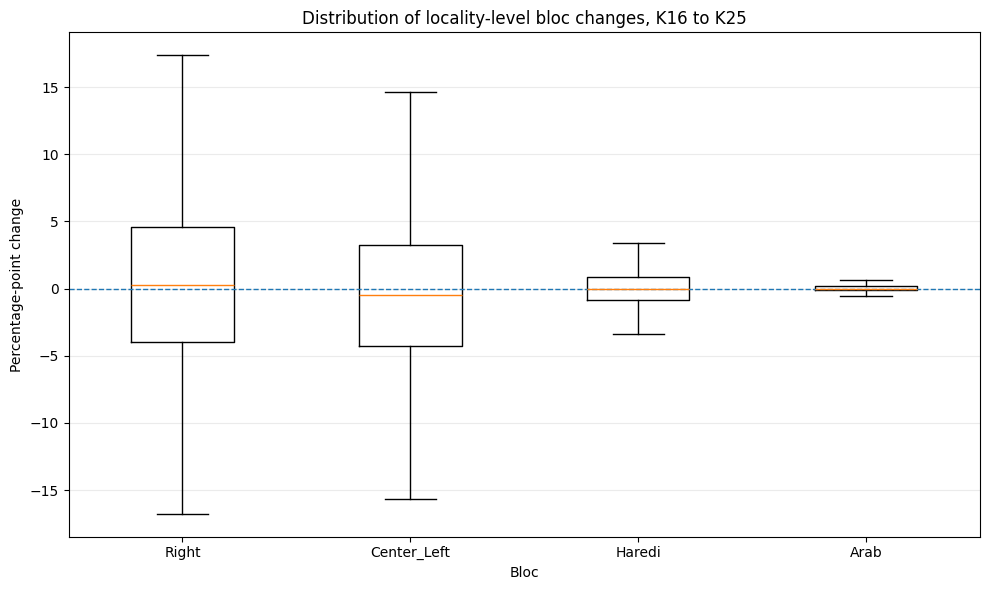

Saved figure: /content/Election_Bloc_Prediction_Project/reports/figures/bloc_change_distributions.png


In [11]:
CHANGE_FIGURE_PATH = (
    FIGURES_DIR
    / "bloc_change_distributions.png"
)

long_delta = (
    transition_panel[delta_columns]
    .rename(
        columns={
            f"delta_{bloc}_pct": bloc
            for bloc in MODELED_BLOCS
        }
    )
    .melt(
        var_name="bloc",
        value_name="delta_pct",
    )
)

figure, axis = plt.subplots(figsize=(10, 6))

axis.boxplot(
    [
        long_delta.loc[
            long_delta["bloc"].eq(bloc),
            "delta_pct",
        ].dropna().to_numpy()
        for bloc in MODELED_BLOCS
    ],
    labels=MODELED_BLOCS,
    showfliers=False,
)

axis.axhline(0, linestyle="--", linewidth=1)
axis.set_title(
    "Distribution of locality-level bloc changes, K16 to K25"
)
axis.set_xlabel("Bloc")
axis.set_ylabel("Percentage-point change")
axis.grid(axis="y", alpha=0.25)
figure.tight_layout()

figure.savefig(
    CHANGE_FIGURE_PATH,
    dpi=160,
    bbox_inches="tight",
)

plt.show()
print("Saved figure:", CHANGE_FIGURE_PATH)

## 9. Save and verify all Notebook 02 outputs

In [12]:
OUTPUT_PATHS = {
    "transition_panel": (
        INTERIM_DIR / "election_transition_panel.csv"
    ),
    "input_election_audit": (
        TABLES_DIR / "notebook_02_input_election_audit.csv"
    ),
    "match_audit": (
        TABLES_DIR / "election_transition_match_audit.csv"
    ),
    "unmatched_localities": (
        TABLES_DIR / "unmatched_localities_by_transition.csv"
    ),
    "transition_overview": (
        TABLES_DIR / "transition_overview.csv"
    ),
    "clr_audit": (
        TABLES_DIR / "clr_transformation_audit.csv"
    ),
    "delta_summary": (
        TABLES_DIR / "bloc_delta_descriptive_summary.csv"
    ),
    "persistence_summary": (
        TABLES_DIR / "persistence_summary_by_transition.csv"
    ),
    "quality_checks": (
        TABLES_DIR / "transition_panel_quality_checks.csv"
    ),
    "change_figure": CHANGE_FIGURE_PATH,
    "summary": (
        SUMMARIES_DIR / "notebook_02_summary.json"
    ),
}

transition_panel.to_csv(
    OUTPUT_PATHS["transition_panel"],
    index=False,
    encoding="utf-8-sig",
)
input_election_audit.to_csv(
    OUTPUT_PATHS["input_election_audit"],
    index=False,
    encoding="utf-8-sig",
)
election_transition_match_audit.to_csv(
    OUTPUT_PATHS["match_audit"],
    index=False,
    encoding="utf-8-sig",
)
unmatched_localities_by_transition.to_csv(
    OUTPUT_PATHS["unmatched_localities"],
    index=False,
    encoding="utf-8-sig",
)
transition_overview.to_csv(
    OUTPUT_PATHS["transition_overview"],
    index=False,
    encoding="utf-8-sig",
)
clr_transformation_audit.to_csv(
    OUTPUT_PATHS["clr_audit"],
    index=False,
    encoding="utf-8-sig",
)
bloc_delta_descriptive_summary.to_csv(
    OUTPUT_PATHS["delta_summary"],
    index=False,
    encoding="utf-8-sig",
)
persistence_summary.to_csv(
    OUTPUT_PATHS["persistence_summary"],
    index=False,
    encoding="utf-8-sig",
)
transition_panel_quality_checks.to_csv(
    OUTPUT_PATHS["quality_checks"],
    index=False,
    encoding="utf-8-sig",
)

summary = {
    "notebook": "02_panel_and_target_engineering",
    "version": "full_history_K16_K25",
    "created_at_utc": time.strftime(
        "%Y-%m-%dT%H:%M:%SZ",
        time.gmtime(),
    ),
    "input": str(SOURCE_PATH.relative_to(REPO_ROOT)),
    "elections": EXPECTED_ELECTION_NUMBERS,
    "transitions": EXPECTED_TRANSITIONS,
    "panel_rows": int(len(transition_panel)),
    "unique_localities": int(
        transition_panel["locality_symbol"].nunique()
    ),
    "minimum_matched_localities": minimum_matched_rows,
    "minimum_previous_vote_coverage_pct": (
        minimum_previous_vote_coverage
    ),
    "minimum_current_vote_coverage_pct": (
        minimum_current_vote_coverage
    ),
    "final_test_transition": FINAL_TEST_TRANSITION,
    "final_test_locked": True,
    "quality_checks_passed": bool(
        transition_panel_quality_checks["passed"].all()
    ),
    "outputs": {
        name: str(path.relative_to(REPO_ROOT))
        for name, path in OUTPUT_PATHS.items()
        if name != "summary"
    },
}

OUTPUT_PATHS["summary"].write_text(
    json.dumps(
        summary,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

output_audit = pd.DataFrame([
    {
        "output": name,
        "relative_path": str(path.relative_to(REPO_ROOT)),
        "exists": path.exists(),
        "size_bytes": (
            path.stat().st_size
            if path.exists()
            else 0
        ),
    }
    for name, path in OUTPUT_PATHS.items()
])

display(output_audit)

bad_outputs = output_audit.loc[
    ~output_audit["exists"]
    | output_audit["size_bytes"].le(0)
]

if not bad_outputs.empty:
    raise RuntimeError(
        "Missing or empty Notebook 02 outputs:\n"
        + bad_outputs.to_string(index=False)
    )

saved_panel = pd.read_csv(
    OUTPUT_PATHS["transition_panel"],
    dtype={"locality_symbol": "string"},
    low_memory=False,
)

saved_transitions = (
    saved_panel["transition_id"]
    .drop_duplicates()
    .tolist()
)

if saved_transitions != EXPECTED_TRANSITIONS:
    raise RuntimeError(
        "The saved transition panel does not contain all nine transitions.\n"
        f"Found: {saved_transitions}"
    )

print("Transitions in saved panel:", saved_transitions)
print("All Notebook 02 files were saved successfully.")

,output,relative_path,exists,size_bytes
0,transition_panel,data/interim/election_transition_panel.csv,True,15164529
1,input_election_audit,reports/tables/notebook_02_input_election_audi...,True,785
2,match_audit,reports/tables/election_transition_match_audit...,True,1201
3,unmatched_localities,reports/tables/unmatched_localities_by_transit...,True,7075
4,transition_overview,reports/tables/transition_overview.csv,True,2230
5,clr_audit,reports/tables/clr_transformation_audit.csv,True,314
6,delta_summary,reports/tables/bloc_delta_descriptive_summary.csv,True,4875
7,persistence_summary,reports/tables/persistence_summary_by_transiti...,True,1484
8,quality_checks,reports/tables/transition_panel_quality_checks...,True,1732
9,change_figure,reports/figures/bloc_change_distributions.png,True,42834


Transitions in saved panel: ['K16_to_K17', 'K17_to_K18', 'K18_to_K19', 'K19_to_K20', 'K20_to_K21', 'K21_to_K22', 'K22_to_K23', 'K23_to_K24', 'K24_to_K25']
All Notebook 02 files were saved successfully.


## 10. Download all Notebook 02 outputs

This final cell is intentionally independent of the `OUTPUT_PATHS` variable. It can be rerun as long as the saved files still exist in the Colab runtime.

In [13]:
from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED
import os

root = Path(
    os.getenv(
        "ELECTION_PROJECT_ROOT",
        "/content/Election_Bloc_Prediction_Project",
    )
)

# Fallback when the repository was located somewhere else.
if not (root / "data/interim/election_transition_panel.csv").exists():
    panel_candidates = list(
        Path("/content").rglob("election_transition_panel.csv")
    )

    if panel_candidates:
        root = panel_candidates[0].parents[2]

relative_files = [
    "data/interim/election_transition_panel.csv",
    "reports/tables/notebook_02_input_election_audit.csv",
    "reports/tables/election_transition_match_audit.csv",
    "reports/tables/unmatched_localities_by_transition.csv",
    "reports/tables/transition_overview.csv",
    "reports/tables/clr_transformation_audit.csv",
    "reports/tables/bloc_delta_descriptive_summary.csv",
    "reports/tables/persistence_summary_by_transition.csv",
    "reports/tables/transition_panel_quality_checks.csv",
    "reports/figures/bloc_change_distributions.png",
    "reports/summaries/notebook_02_summary.json",
]

zip_path = Path("/content/notebook_02_outputs.zip")

if zip_path.exists():
    zip_path.unlink()

added_files = []
missing_files = []

with ZipFile(
    zip_path,
    mode="w",
    compression=ZIP_DEFLATED,
) as zip_file:
    for relative_file in relative_files:
        file_path = root / relative_file

        if file_path.exists() and file_path.stat().st_size > 0:
            zip_file.write(file_path, arcname=relative_file)
            added_files.append(relative_file)
        else:
            missing_files.append(relative_file)

if not added_files:
    raise FileNotFoundError(
        "No Notebook 02 output files were found. "
        "Run the save cell first."
    )

print("ZIP created:", zip_path)
print("ZIP size:", zip_path.stat().st_size, "bytes")
print("Files added:", len(added_files))

for relative_file in added_files:
    print("Added:", relative_file)

for relative_file in missing_files:
    print("Skipped because it was not found:", relative_file)

from google.colab import files
files.download(str(zip_path))

ZIP created: /content/notebook_02_outputs.zip
ZIP size: 5283418 bytes
Files added: 11
Added: data/interim/election_transition_panel.csv
Added: reports/tables/notebook_02_input_election_audit.csv
Added: reports/tables/election_transition_match_audit.csv
Added: reports/tables/unmatched_localities_by_transition.csv
Added: reports/tables/transition_overview.csv
Added: reports/tables/clr_transformation_audit.csv
Added: reports/tables/bloc_delta_descriptive_summary.csv
Added: reports/tables/persistence_summary_by_transition.csv
Added: reports/tables/transition_panel_quality_checks.csv
Added: reports/figures/bloc_change_distributions.png
Added: reports/summaries/notebook_02_summary.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Completion criteria

The notebook is complete only when the output includes:

```text
Input validation passed.
Transitions created: ['K16_to_K17', ..., 'K24_to_K25']
All Notebook 02 quality checks passed.
Transitions in saved panel: ['K16_to_K17', ..., 'K24_to_K25']
All Notebook 02 files were saved successfully.
```

The central input for Notebook 03 is:

```text
data/interim/election_transition_panel.csv
```